In [34]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load and preprocess data (similar to original)
data = pd.read_parquet("sales_features.parquet").reset_index()
data = data.sort_values(["store", "date"])
data["time_idx"] = data.groupby("store").cumcount() + 1

# Filter stores (keep original logic)
store_time_counts = data.groupby("store")["time_idx"].count()
valid_stores = store_time_counts[store_time_counts >= 30 + 7].index
data = data[data["store"].isin(valid_stores)]

# Simplified feature engineering
categorical_features = ["store", "month", "is_holiday"]
numeric_features = [
    "sale_dollars", "day_of_month", 
    "sale_dollars_rolling_mean_7D",
    "days_to_nearest_holiday"
]

# Encode categorical features
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# Normalize numeric features
scaler = StandardScaler()
data[numeric_features] = scaler.fit_transform(data[numeric_features])

# Create sliding windows (simplified version)
def create_sequences(data, window_size, forecast_horizon):
    sequences = []
    targets = []
    stores = data["store"].unique()
    
    for store in stores:
        store_data = data[data["store"] == store].sort_values("time_idx")
        values = store_data[numeric_features + categorical_features].values
        
        for i in range(len(values) - window_size - forecast_horizon):
            sequences.append(values[i:i+window_size])
            targets.append(values[i+window_size:i+window_size+forecast_horizon, 0])  # First feature is sale_dollars
            
    return np.array(sequences), np.array(targets)

X, y = create_sequences(data, window_size=30, forecast_horizon=7)

# Split data
split_idx = int(0.8 * len(X))
train_X, test_X = X[:split_idx], X[split_idx:]
train_y, test_y = y[:split_idx], y[split_idx:]

# Build simplified temporal model
def build_temporal_model(input_shape, forecast_horizon):
    inputs = layers.Input(shape=input_shape)
    
    # Temporal processing
    x = layers.LSTM(64, return_sequences=True)(inputs)
    x = layers.LSTM(32)(x)
    
    # Dense processing for multi-step forecast
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(forecast_horizon)(x)
    
    model = models.Model(inputs, outputs)
    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=[tf.keras.metrics.RootMeanSquaredError()]
    )
    return model

model = build_temporal_model(
    input_shape=(30, len(numeric_features) + len(categorical_features)),
    forecast_horizon=7
)

# Train with early stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

history = model.fit(
    train_X, train_y,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop]
)

# Evaluate
test_results = model.evaluate(test_X, test_y)
print(f"Test RMSE: {test_results[1]:.2f}")

# Generate predictions
test_preds = model.predict(test_X)

Epoch 1/50
1762/1762 [==============================] - 19s 10ms/step - loss: 1.1284 - root_mean_squared_error: 1.0623 - val_loss: 0.1200 - val_root_mean_squared_error: 0.3464
Epoch 2/50
1762/1762 [==============================] - 9s 5ms/step - loss: 1.0369 - root_mean_squared_error: 1.0183 - val_loss: 0.1183 - val_root_mean_squared_error: 0.3439
Epoch 3/50
1762/1762 [==============================] - 9s 5ms/step - loss: 1.0319 - root_mean_squared_error: 1.0158 - val_loss: 0.1088 - val_root_mean_squared_error: 0.3299
Epoch 4/50
1762/1762 [==============================] - 14s 8ms/step - loss: 1.0245 - root_mean_squared_error: 1.0122 - val_loss: 0.1145 - val_root_mean_squared_error: 0.3383
Epoch 5/50
1762/1762 [==============================] - 17s 10ms/step - loss: 1.0228 - root_mean_squared_error: 1.0113 - val_loss: 0.1260 - val_root_mean_squared_error: 0.3549
Epoch 6/50
1762/1762 [==============================] - 14s 8ms/step - loss: 1.0212 - root_mean_squared_error: 1.0105 - val_l

In [35]:
# Generate predictions
test_preds = model.predict(test_X)

1102/1102 [==============================] - 4s 4ms/step


In [40]:
scaler.inverse_transform(test_preds)

ValueError: operands could not be broadcast together with shapes (35238,7) (4,) (35238,7) 

In [37]:
test_y

array([[-0.34866096, -0.29941113, -0.20140864, ..., -0.05301715,
         0.01894369, -0.44186059],
       [-0.29941113, -0.20140864, -0.16198175, ...,  0.01894369,
        -0.44186059, -0.05383774],
       [-0.20140864, -0.16198175, -0.05301715, ..., -0.44186059,
        -0.05383774, -0.30933061],
       ...,
       [-0.20761616,  0.22310629,  0.23440628, ..., -0.14996735,
         0.07170275, -0.29775547],
       [ 0.19817003,  0.24112063, -0.01115745, ...,  0.1771726 ,
         0.02043041,  0.20607665],
       [-0.33186302, -0.07641843, -0.32801108, ..., -0.08354307,
        -0.22490646, -0.17807495]])

1102/1102 [==============================] - 4s 4ms/step


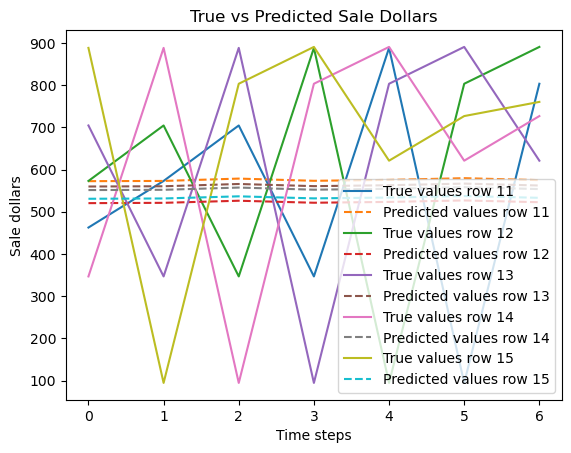

In [28]:

import matplotlib.pyplot as plt

# Ensure the model is defined and trained
# Generate predictions
test_preds = model.predict(test_X)

# Plot first 3 rows of test_preds and test_y
for i in range(10, 15):
    plt.plot(test_y[i], label=f'True values row {i+1}')
    plt.plot(test_preds[i], linestyle='--', label=f'Predicted values row {i+1}')

plt.xlabel('Time steps')
plt.ylabel('Sale dollars')
plt.title('True vs Predicted Sale Dollars')
plt.legend()
plt.show()
